In [42]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1번 문제

In [43]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

In [46]:
# CSV Load
# df_first = pd.read_csv('C:/ai_x/download/shareData/부동산_20250430/전국평균평당분양가2015년8월.csv', encoding='cp949')
df_first = pd.read_csv('C:/ksmindpks/데이터다운로드/부동산_20250430/전국평균평당분양가2015년8월.csv', encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449


In [47]:
# 데이터 프레임 결측치 확인
df_first.isna().sum()

지역          0
2013년12월    0
2014년1월     0
2014년2월     0
2014년3월     0
2014년4월     0
2014년5월     0
2014년6월     0
2014년7월     0
2014년8월     0
2014년9월     0
2014년10월    0
2014년11월    0
2014년12월    0
2015년1월     0
2015년2월     0
2015년3월     0
2015년4월     0
2015년5월     0
2015년6월     0
2015년7월     0
2015년8월     0
dtype: int64

In [48]:
# set_index
df_first.set_index('지역', inplace=True)
df_first.tail()

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,6719,...,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580
전남,5678,5678,5678,5696,5736,5656,5609,5780,5685,5804,...,5768,5784,5784,5833,5825,5940,6050,6243,6286,6289
경북,6168,6168,6234,6317,6412,6409,6554,6556,6563,6577,...,6881,6989,6992,6953,6997,7006,6966,6887,7035,7037
경남,6473,6485,6502,6610,6599,6610,6615,6613,6606,6767,...,7125,7332,7592,7588,7668,7683,7717,7715,7723,7665
제주,7674,7900,7900,7900,7900,7900,7914,7914,7914,7833,...,7724,7739,7739,7739,7826,7285,7285,7343,7343,7343


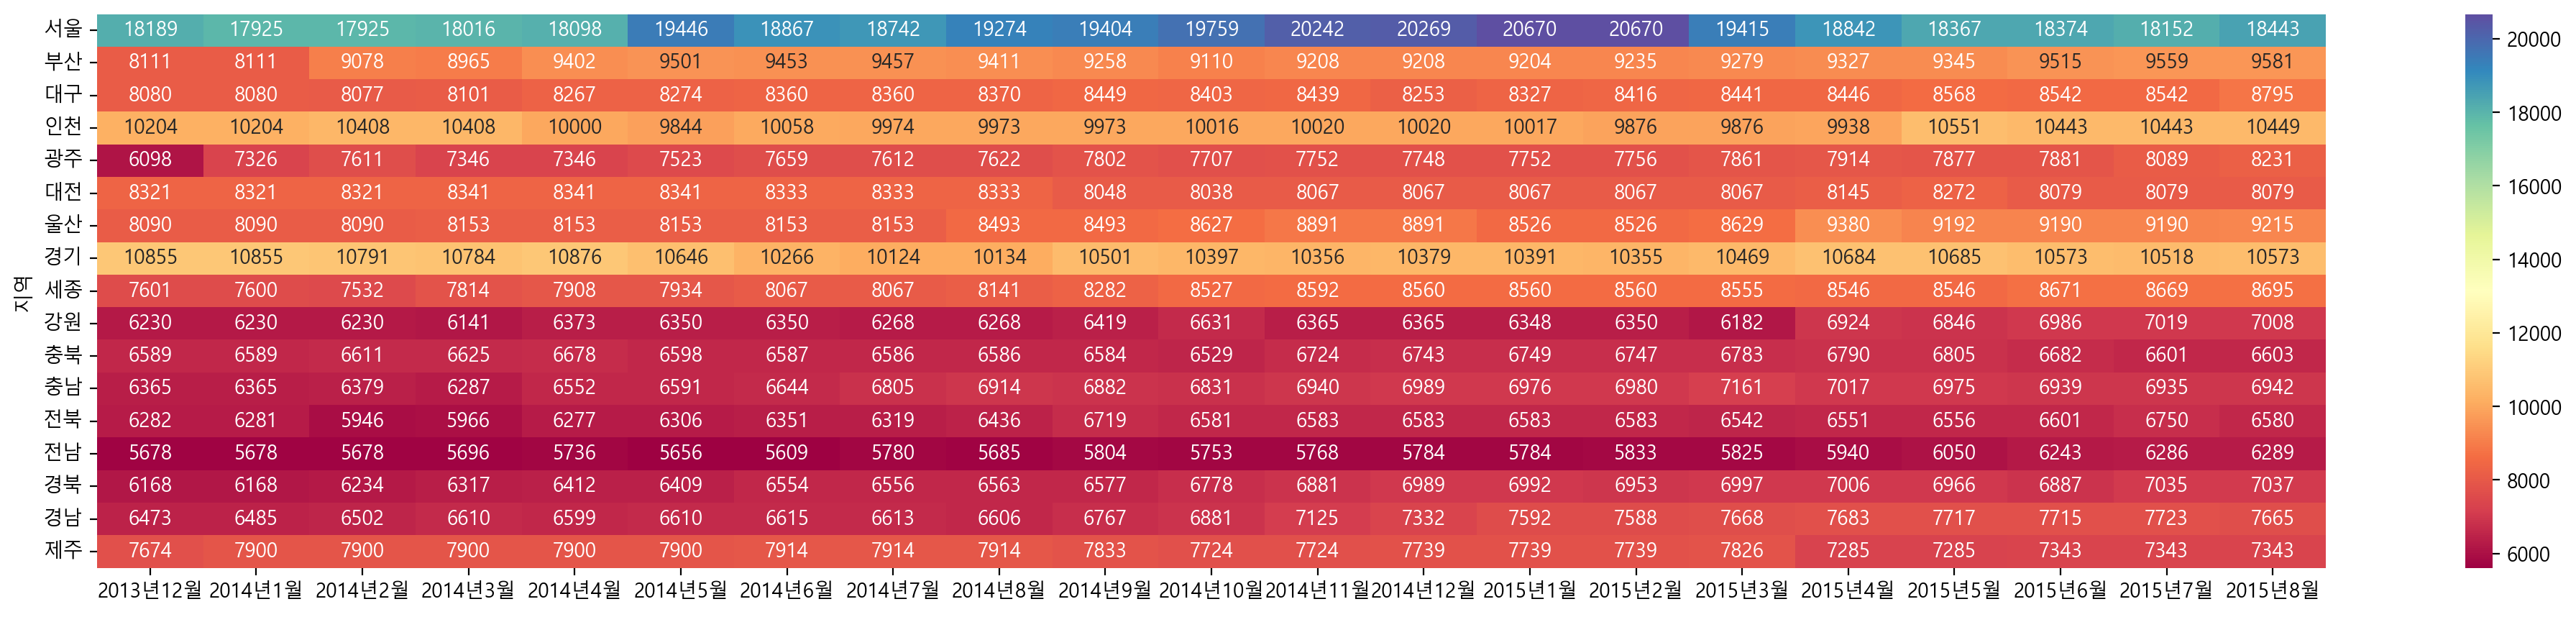

In [49]:
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Spectral', cbar=True)
plt.xticks(rotation=0)
plt.show()

# 2번 문제

In [50]:
# df_last = pd.read_csv('C:/ai_x/download/shareData/부동산_20250430/전국신규아파트분양가격_20241231.csv', encoding='cp949')
df_last = pd.read_csv('C:/ksmindpks/데이터다운로드/부동산_20250430/전국신규아파트분양가격_20241231.csv', encoding='cp949')
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [51]:
# 분양가격(제곱미터) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()
# ex['분양가격(제곱미터)'].astype('float64') # 에러 이유 : '  '
pd.to_numeric(df_last['분양가격(제곱미터)'], errors='coerce').isna().sum()

740

In [52]:
# 분양가격(제곱미터) 컬럼이 space인 행 : 740-614=126개
df_last[df_last['분양가격(제곱미터)'].str.strip() == ''].head()

,지역명,규모구분,연도,월,분양가격(제곱미터)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,
29,광주,전용면적 102제곱미터초과,2015,10,
34,대전,전용면적 102제곱미터초과,2015,10,
81,제주,전용면적 60제곱미터이하,2015,10,
113,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,11,


In [53]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    price = row['분양가격(제곱미터)']
    if pd.notnull(price) and price.strip()!='':
        return len(price)
    else:
        return 0

In [54]:
df_last['자리수'] = df_last.apply(get_pricelen, axis=1)
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [17]:
df_last.index.name = 'idx'
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
idx,,,,,,
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [18]:
df_last = df_last.reset_index()
df_last.head(2)

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,5841,4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [19]:
# 분양가격 컬럼에 콤마(,) 제거 & 공백문자가 있는 경우 np.nan로 바꾸는 함수 정의
def commadrop(row):
    row = row.copy()
    price = row['분양가격(제곱미터)']
    if pd.isna(price): # np.nan이거나 None인지 여부
        row['제곱미터분양가격'] = np.nan
    elif price.strip() =='': # space면 np.nan로
        row['제곱미터분양가격'] = np.nan
    elif price.find(',')!=-1: # 콤마가 있으면 콤마 없애기
        row['제곱미터분양가격'] = ''.join(price.split(','))
    else:
        row['제곱미터분양가격'] = price
    return row

In [20]:
# 2022년 데이터 흉내내기 위한 함수  : 매개변수로 row로 받아 nan, ' ', '  ', '5123', '5,123' return
def comma_append(row):
    price = row['분양가격(제곱미터)']
    if (row.idx%5==0) & (row.자리수>=4):
        price = price[:-3] + ',' + price[-3:]
    return price

In [21]:
df_last['분양가격(제곱미터)'] = df_last.apply(comma_append, axis=1)
df_last.head(2)

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,"5,841",4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [22]:
df_last.drop(['idx', '자리수'], axis=1, inplace=True)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터)
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,7950


In [23]:
# 공백문자는 결측치로, 콤마 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터분양가격
9090,제주,모든면적,2024,8,"7,703",7703
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,7950,7950


In [24]:
df_last['제곱미터분양가격'] = df_last['제곱미터분양가격'].astype(np.float64)
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터분양가격    8355 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 426.5+ KB


In [25]:
# 평당분양 가격 추가
df_last['평당분양가격'] = df_last['제곱미터분양가격']*3.3
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터분양가격,평당분양가격
9090,제주,모든면적,2024,8,"7,703",7703.0,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515.0,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,7950,7950.0,26235.0


In [26]:
df_last.drop(['제곱미터분양가격', '분양가격(제곱미터)'], axis=1, inplace=True)
df_last.tail()

,지역명,규모구분,연도,월,평당분양가격
9090,제주,모든면적,2024,8,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,26235.0


In [27]:
# 규모구분 칼럼을 중복단어를 제외하고 전용면적 칼럼으로
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','')\
                .str.replace('제곱미터','m²')\
                .str.replace('초과','~')\
                .str.replace('이하','').str.replace(' ', '')
df_last['전용면적']

0             모든면적
1             60m²
2        60m²~85m²
3       85m²~102m²
4           102m²~
           ...    
9090          모든면적
9091          60m²
9092     60m²~85m²
9093    85m²~102m²
9094        102m²~
Name: 전용면적, Length: 9095, dtype: object

In [28]:
df_last.drop(['규모구분'], axis=1, inplace=True)
df_last

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,모든면적
1,서울,2015,10,18651.6,60m²
2,서울,2015,10,19410.6,60m²~85m²
3,서울,2015,10,18879.3,85m²~102m²
4,서울,2015,10,19400.7,102m²~
...,...,...,...,...,...
9090,제주,2024,8,25419.9,모든면적
9091,제주,2024,8,NaN,60m²
9092,제주,2024,8,24799.5,60m²~85m²
9093,제주,2024,8,NaN,85m²~102m²


In [29]:
new_last = df_last[df_last.전용면적 == '모든면적'].copy()
new_last.drop('전용면적', axis=1, inplace=True)
new_last.head()

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
5,인천,2015,10,10437.9
10,경기,2015,10,10355.4
15,부산,2015,10,10269.6
20,대구,2015,10,8850.6


# 3번 문제

In [30]:
# 연도별, 지역명별 평당분양가격을 집계
r = df_last.pivot_table(index='연도',
                   columns='지역명',
                   values='평당분양가격').round()
r

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.0,11061.0,8459.0,7464.0,7917.0,9019.0,8191.0,10377.0,20316.0,8765.0,9368.0,10976.0,6799.0,7110.0,7951.0,7690.0,6829.0
2016,7163.0,11685.0,8497.0,7753.0,9191.0,10282.0,8911.0,10744.0,21753.0,8858.0,9583.0,11099.0,6937.0,6907.0,9567.0,7958.0,7133.0
2017,7319.0,12296.0,8807.0,8288.0,9600.0,12192.0,9913.0,11638.0,21864.0,9133.0,10630.0,11672.0,7413.0,7406.0,12629.0,8157.0,7463.0
2018,8219.0,14258.0,9328.0,8681.0,9527.0,12139.0,10234.0,12890.0,23202.0,10340.0,10241.0,11882.0,7930.0,8175.0,11936.0,8202.0,8149.0
2019,8934.0,15666.0,10698.0,9050.0,12112.0,14082.0,12619.0,13538.0,28287.0,11299.0,10216.0,13250.0,8219.0,8532.0,11828.0,8749.0,7971.0
2020,10302.0,15106.0,10919.0,9998.0,13406.0,15314.0,11239.0,13353.0,29781.0,11628.0,12838.0,14983.0,9562.0,8559.0,14193.0,9139.0,8359.0
2021,10291.0,14567.0,11302.0,11227.0,13710.0,15586.0,11994.0,14318.0,29380.0,12578.0,14192.0,15774.0,9981.0,9048.0,22302.0,9861.0,8822.0
2022,11644.0,16622.0,12456.0,12018.0,15096.0,16822.0,14114.0,18167.0,29129.0,11310.0,17904.0,17342.0,10636.0,10003.0,18954.0,11730.0,10034.0
2023,13409.0,20175.0,13283.0,13025.0,17958.0,17657.0,17917.0,20471.0,33231.0,12278.0,18832.0,16151.0,11847.0,10966.0,24096.0,12581.0,11104.0


In [31]:
r = df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack().round()
r

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.0,11061.0,8459.0,7464.0,7917.0,9019.0,8191.0,10377.0,20316.0,8765.0,9368.0,10976.0,6799.0,7110.0,7951.0,7690.0,6829.0
2016,7163.0,11685.0,8497.0,7753.0,9191.0,10282.0,8911.0,10744.0,21753.0,8858.0,9583.0,11099.0,6937.0,6907.0,9567.0,7958.0,7133.0
2017,7319.0,12296.0,8807.0,8288.0,9600.0,12192.0,9913.0,11638.0,21864.0,9133.0,10630.0,11672.0,7413.0,7406.0,12629.0,8157.0,7463.0
2018,8219.0,14258.0,9328.0,8681.0,9527.0,12139.0,10234.0,12890.0,23202.0,10340.0,10241.0,11882.0,7930.0,8175.0,11936.0,8202.0,8149.0
2019,8934.0,15666.0,10698.0,9050.0,12112.0,14082.0,12619.0,13538.0,28287.0,11299.0,10216.0,13250.0,8219.0,8532.0,11828.0,8749.0,7971.0
2020,10302.0,15106.0,10919.0,9998.0,13406.0,15314.0,11239.0,13353.0,29781.0,11628.0,12838.0,14983.0,9562.0,8559.0,14193.0,9139.0,8359.0
2021,10291.0,14567.0,11302.0,11227.0,13710.0,15586.0,11994.0,14318.0,29380.0,12578.0,14192.0,15774.0,9981.0,9048.0,22302.0,9861.0,8822.0
2022,11644.0,16622.0,12456.0,12018.0,15096.0,16822.0,14114.0,18167.0,29129.0,11310.0,17904.0,17342.0,10636.0,10003.0,18954.0,11730.0,10034.0
2023,13409.0,20175.0,13283.0,13025.0,17958.0,17657.0,17917.0,20471.0,33231.0,12278.0,18832.0,16151.0,11847.0,10966.0,24096.0,12581.0,11104.0


# 4번 문제

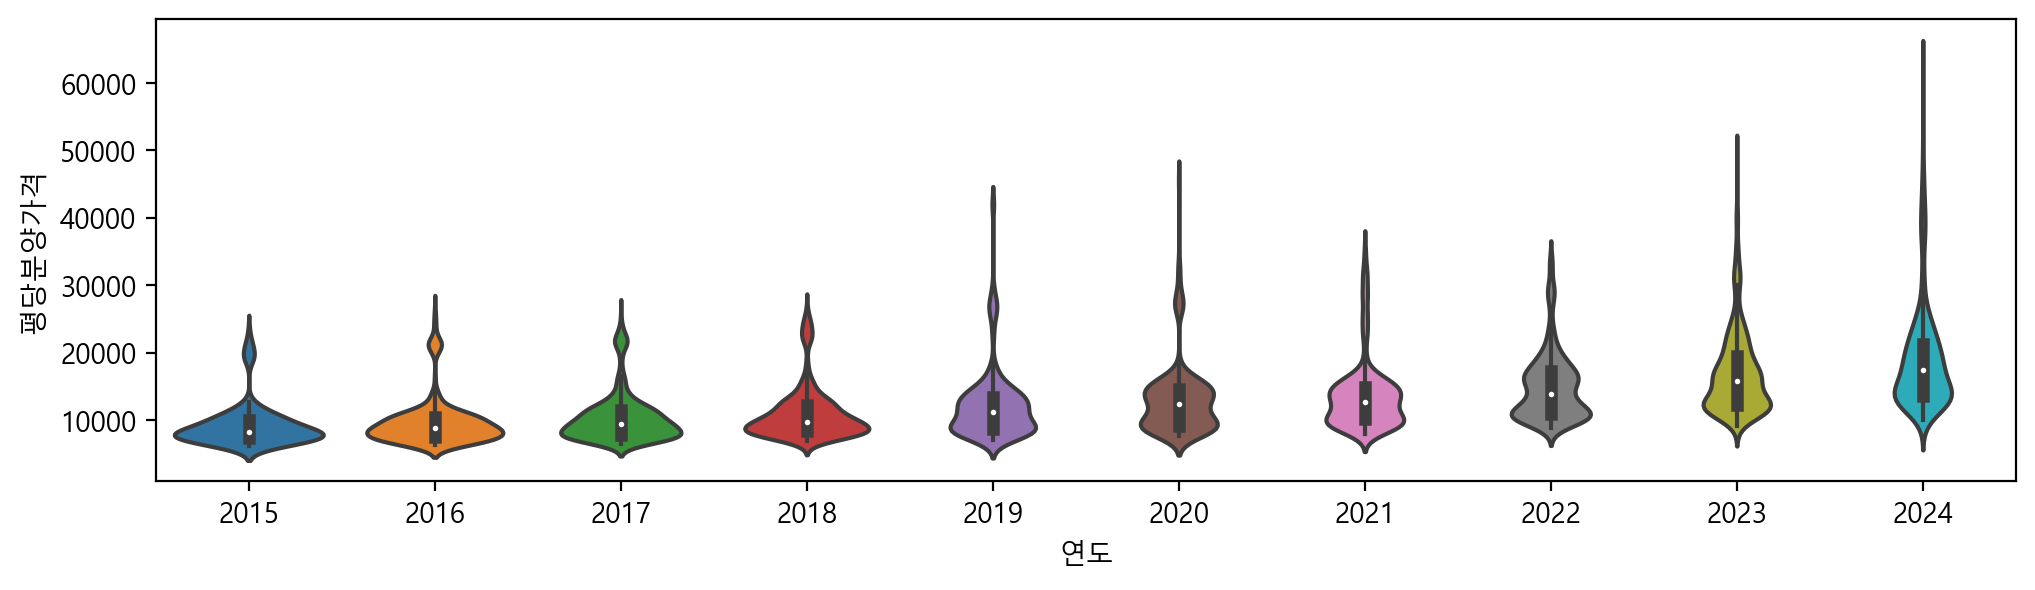

In [32]:
# boxplot에 분포 추정 가능한 그래프
plt.figure(figsize=(12,3))
sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

# 5번 문제

In [33]:
df_first.sample(3)

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
경북,6168,6168,6234,6317,6412,6409,6554,6556,6563,6577,...,6881,6989,6992,6953,6997,7006,6966,6887,7035,7037
충북,6589,6589,6611,6625,6678,6598,6587,6586,6586,6584,...,6724,6743,6749,6747,6783,6790,6805,6682,6601,6603


In [34]:
df_first.reset_index(inplace=True)
df_first.sample(3)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
13,전남,5678,5678,5678,5696,5736,5656,5609,5780,5685,...,5768,5784,5784,5833,5825,5940,6050,6243,6286,6289
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573


In [35]:
# 데이터 구조 동일하게
new_first = df_first.melt(id_vars='지역',
             var_name='연도월',
             value_name='평당분양가격')
new_first.sample()

,지역,연도월,평당분양가격
18,부산,2014년1월,8111


In [36]:
new_first['연도'] = new_first['연도월'].map(lambda data : int(data.split('년')[0]))
new_first.head()

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013
1,부산,2013년12월,8111,2013
2,대구,2013년12월,8080,2013
3,인천,2013년12월,10204,2013
4,광주,2013년12월,6098,2013


In [37]:
new_first['월'] = new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))
new_first.head()

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12
1,부산,2013년12월,8111,2013,12
2,대구,2013년12월,8080,2013,12
3,인천,2013년12월,10204,2013,12
4,광주,2013년12월,6098,2013,12


In [38]:
new_first.drop('연도월', axis=1, inplace=True)
new_first.head()

,지역,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


In [39]:
new_first.columns = ['지역명','평당분양가격','연도','월']
new_first.head() # new_first concat 준비 완료

,지역명,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


In [40]:
df = pd.concat([new_first, new_last], axis=0)
df.index

Int64Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
            ...
            9045, 9050, 9055, 9060, 9065, 9070, 9075, 9080, 9085, 9090],
           dtype='int64', length=2176)

In [41]:
# df의 index reset
df.reset_index(drop=True, inplace=True)
df

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
2171,전북,12058.2,2024,8
2172,전남,13120.8,2024,8
2173,경북,13827.0,2024,8
2174,경남,13252.8,2024,8
